In [ ]:
# If you don't already have these in your environment, remove lines you don't need
!pip install -q geopandas shapely pyproj rasterio folium hdbscan pulp osmnx fiona tqdm scikit-learn


In [3]:
import pandas as pd
import elevation
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
import requests
import osmnx as ox
import geopandas as gpd
import folium
from folium.plugins import HeatMap
import matplotlib.colors as colors
import numpy as np
from owslib.wcs import WebCoverageService
import os
import json
from shapely.geometry import box, mapping, Point, shape
import pyproj
from shapely.ops import transform
from shapely.ops import unary_union
from pyproj import Transformer
from rasterio.features import shapes
from sklearn.cluster import DBSCAN
import hdbscan
from pyproj import Transformer
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import geopandas as gpd
import numpy as np
from folium.plugins import MarkerCluster, MiniMap
from branca.colormap import LinearColormap
from folium import LayerControl
from scipy.spatial import distance_matrix
import math
from rasterio.plot import show



In [4]:
#Location Boundary for Cork
min_lon, max_lon = -10.0, -7.5
min_lat, max_lat = 51.4, 52.4

Data Preprocessing
1. WorldPop density

In [5]:
#Population Dataset
pop_df = pd.read_csv("Datasets/Ireland_pop/irl_pd_2020_1km_UNadj_ASCII_XYZ.csv")
pop_df.head()

,X,Y,Z
0,-7.255417,55.445417,2.091383
1,-7.238750,55.437083,18.468687
2,-7.230417,55.437083,2.603163
3,-7.222083,55.437083,2.227272
4,-7.247083,55.428750,3.857233


In [6]:
# Remove missing coordinates
pop_df = pop_df.dropna(subset=['X', 'Y'])
# Keep valid coordinate ranges
pop_df = pop_df[(pop_df['X'].between(-180, 180)) & (pop_df['Y'].between(-90, 90))]

In [7]:
# Filtering to Cork area
pop_df = pop_df[(pop_df['X'] >= min_lon) & (pop_df['X'] <= max_lon) & (pop_df['Y'] >= min_lat) & (pop_df['Y'] <= max_lat)]
print(f"Filtered population points: {len(pop_df)}")

Filtered population points: 25629


In [8]:
# Keeping only positive population densities
pop_df = pop_df[pop_df['Z'] > 0]

In [9]:
# Create geometry column
geometry = [Point(xy) for xy in zip(pop_df['X'], pop_df['Y'])]
pop_gdf = gpd.GeoDataFrame(pop_df, geometry=geometry, crs="EPSG:4326")
print(pop_gdf.head())

               X          Y          Z                   geometry
107750 -9.922083  52.395417  29.055517  POINT (-9.92208 52.39542)
107751 -9.913750  52.395417  63.731602  POINT (-9.91375 52.39542)
107752 -9.905417  52.395417  24.310961  POINT (-9.90542 52.39542)
107753 -9.897083  52.395417  20.980133  POINT (-9.89708 52.39542)
107754 -9.888750  52.395417  37.825783  POINT (-9.88875 52.39542)


In [10]:
# Save to GeoPackage for future use
pop_gdf.to_file("population_clean.gpkg", driver="GPKG")
print("Cleaned population data saved as population_clean.gpkg")

Cleaned population data saved as population_clean.gpkg


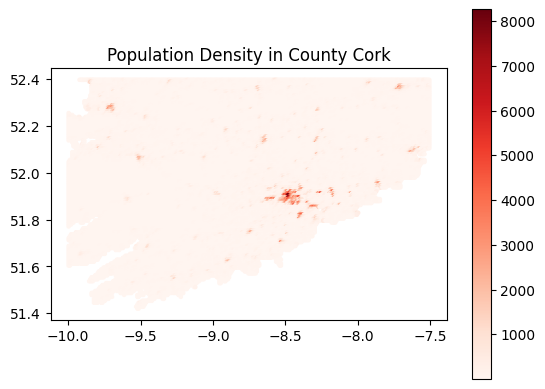

In [11]:
pop_gdf.plot(column='Z', cmap='Reds', legend=True, markersize=5)
plt.title("Population Density in County Cork")
plt.show()

2. Existing Cell locations

In [12]:
#Exisiting Tower Data
tower_df = pd.read_csv("Datasets/Existing_Tower/exisiting_tower.csv")
# Assign temporary column names based on your example
tower_df.columns = ['Network', 'MCC', 'MNC', 'LAC', 'CID', 'Unit', 'Longitude', 'Latitude', 'Range', 'Samples', 'Changeable', 'Created', 'Updated', 'AverageSignal']
tower_df.head()

,Network,MCC,MNC,LAC,CID,Unit,Longitude,Latitude,Range,Samples,Changeable,Created,Updated,AverageSignal
0,LTE,272,3,40072,10572555,0,-6.4356,53.2933,1482,79,1,1562254383,1720070716,0
1,LTE,272,5,40102,336642,0,-6.2696,53.3468,1000,5,1,1563207261,1734722102,0
2,LTE,272,5,40100,294144,0,-6.2796,53.3480,1000,8,1,1563207427,1729448223,0
3,LTE,272,5,40100,294145,0,-6.2815,53.3463,1000,13,1,1563293773,1729448223,0
4,LTE,272,5,40100,294166,0,-6.2847,53.3467,1000,13,1,1563347174,1711034849,0


In [13]:
# Remove missing coordinates
tower_df = tower_df.dropna(subset=['Longitude', 'Latitude'])

# Keep valid coordinate ranges
tower_df = tower_df[(tower_df['Longitude'].between(-180, 180)) & (tower_df['Latitude'].between(-90, 90))]

tower_df = tower_df[(tower_df['Longitude'] >= min_lon) & (tower_df['Longitude'] <= max_lon) &
                    (tower_df['Latitude'] >= min_lat) & (tower_df['Latitude'] <= max_lat)]

print(f"Remaining towers after filtering: {len(tower_df)}")

Remaining towers after filtering: 333


In [14]:
# Create geometry points
geometry = [Point(xy) for xy in zip(tower_df['Longitude'], tower_df['Latitude'])]
tower_gdf = gpd.GeoDataFrame(tower_df, geometry=geometry, crs="EPSG:4326")

In [15]:
# Save to GeoPackage
tower_gdf.to_file("existing_towers_clean.gpkg", driver="GPKG")
print("Cleaned tower data saved as existing_towers_clean.gpkg")

Cleaned tower data saved as existing_towers_clean.gpkg


In [16]:
# Reproject to Irish Transverse Mercator (EPSG:29902) for accurate meters-based calculations
tower_gdf_m = tower_gdf.to_crs(epsg=29902)
# Create buffer circles based on range column (radius in meters)
tower_gdf_m['coverage_area'] = tower_gdf_m.buffer(tower_gdf_m['Range'])
print(tower_gdf_m.head())


    Network  MCC  MNC    LAC       CID  Unit  Longitude  Latitude  Range  \
6       LTE  272    5  42600    336902     0    -9.0547   51.7318  12956   
42      LTE  272    3  40122  11016961     0    -8.3898   51.9439   2722   
354     LTE  272    3  40122  10946326     0    -8.4627   51.8945   1000   
355     LTE  272    3  40122  10946316     0    -8.4646   51.8939   1000   
716     LTE  272    3  40122  11181314    -1    -9.2263   51.5641   1947   

     Samples  Changeable     Created     Updated  AverageSignal  \
6          5           1  1564060357  1720463291              0   
42        42           1  1579626095  1727501715              0   
354       17           1  1647714216  1707146971              0   
355        2           1  1647715104  1726981382              0   
716       36           1  1663744018  1716784603              0   

                         geometry  \
6    POINT (127181.674 53732.142)   
42   POINT (173244.907 76877.585)   
354  POINT (168196.968 71410.

/tmp/ipykernel_5952/3343197609.py:12: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


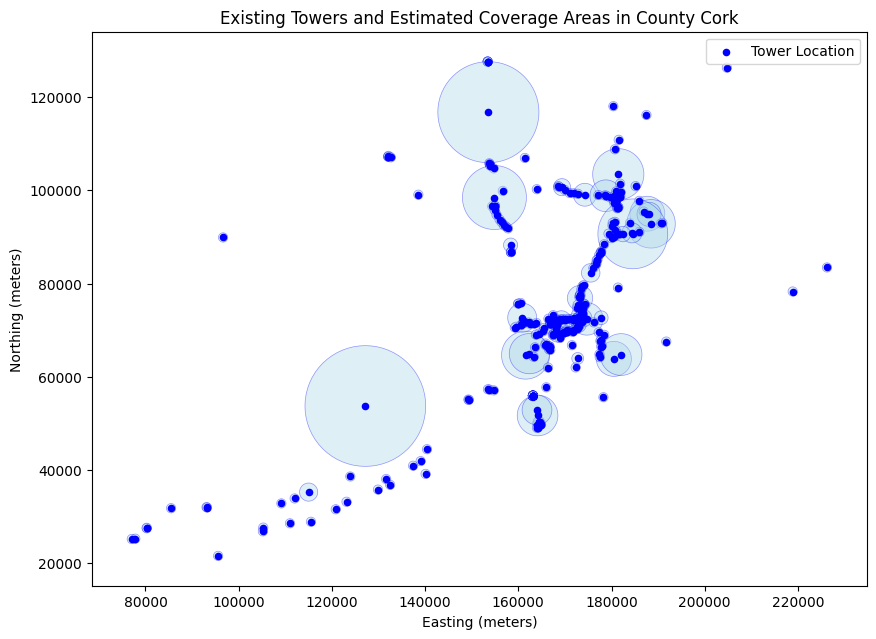

In [17]:
# Plotting the coverage areas and tower locations
fig, ax = plt.subplots(figsize=(10, 10))

# Plot coverage circles
tower_gdf_m.set_geometry('coverage_area').plot(ax=ax, color='lightblue', alpha=0.4, edgecolor='blue', linewidth=0.5, label='Coverage Area')

# Plot tower locations
tower_gdf_m.set_geometry('geometry').plot(ax=ax, color='Blue', markersize=20, label='Tower Location')
plt.title("Existing Towers and Estimated Coverage Areas in County Cork")
plt.xlabel("Easting (meters)")
plt.ylabel("Northing (meters)")
plt.legend()
plt.show()

3. Elevation Data

✅ Downloaded County Cork elevation data.


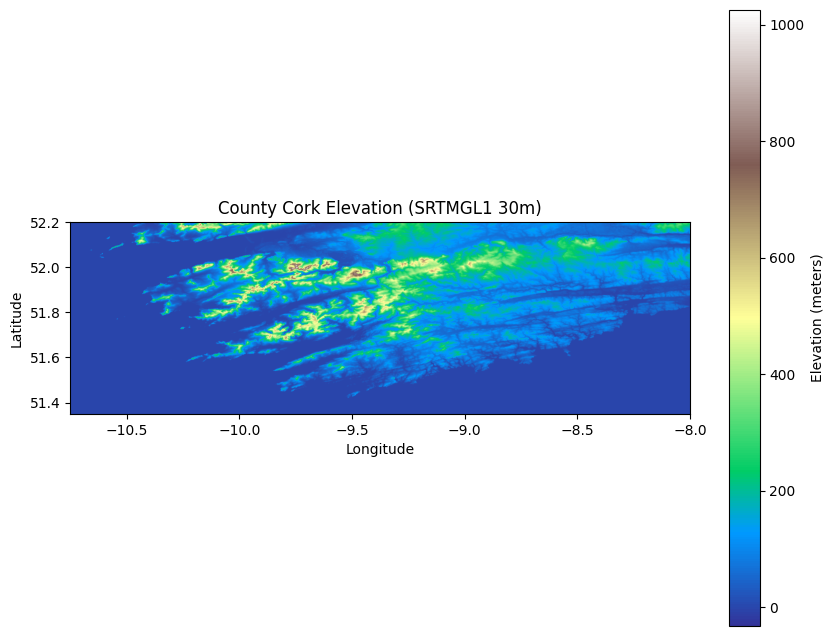

In [18]:
import requests
import rasterio
import matplotlib.pyplot as plt

# === Step 1: Define bounding box for County Cork ===
min_lat = 51.35
max_lat = 52.20
min_lon = -10.75
max_lon = -8.00

# === Step 2: OpenTopography API endpoint and key ===
url = "https://portal.opentopography.org/API/globaldem"
API_KEY = "0f916fa086e955783da65267877ef763"

params = {
    "demtype": "SRTMGL1",       # 30m resolution
    "south": min_lat,
    "north": max_lat,
    "west": min_lon,
    "east": max_lon,
    "outputFormat": "GTiff",
    "API_Key": API_KEY
}

# === Step 3: Request data from OpenTopography ===
response = requests.get(url, params=params)

if response.status_code == 200:
    with open("cork_srtmgl1.tif", "wb") as f:
        f.write(response.content)
    print("Downloaded County Cork elevation data.")
else:
    print(f"Error: {response.status_code} - {response.text}")

# === Step 4: Plot elevation using rasterio and matplotlib ===
with rasterio.open("cork_srtmgl1.tif") as src:
    elev = src.read(1)
    plt.figure(figsize=(10, 8))
    plt.imshow(elev, cmap="terrain", extent=(min_lon, max_lon, min_lat, max_lat))
    plt.title("County Cork Elevation (SRTMGL1 30m)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.colorbar(label="Elevation (meters)")
    plt.show()

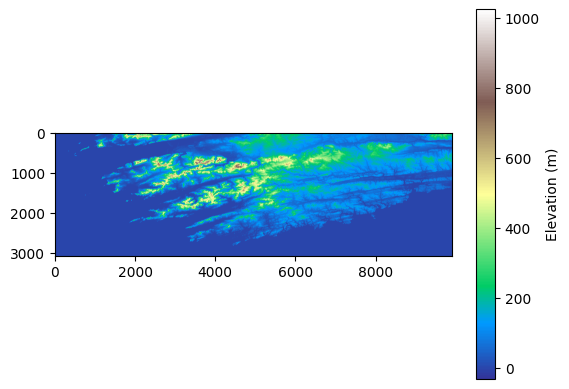

In [19]:
with rasterio.open("cork_srtmgl1.tif") as src:
    elev = src.read(1)
    plt.imshow(elev, cmap="terrain")
    plt.colorbar(label="Elevation (m)")
    plt.show()

4. Admin Boundaries

<Axes: >

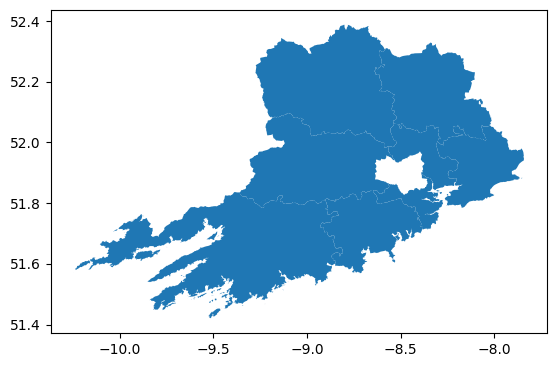

In [20]:
#Administrative boundaries
gdf_admin = gpd.read_file("Datasets/Legal/gadm41_IRL_shp/gadm41_IRL_2.shp")
gdf_admin = gdf_admin.to_crs(epsg=4326)  # Ensure CRS is WGS84

gdf_admin = gdf_admin[gdf_admin['NAME_1'] == 'Cork']  # Filter for Cork County
gdf_admin.plot()

5. Road Networks

In [21]:
# Download road network for County Cork
place = "County Cork, Ireland"
G = ox.graph_from_place(place, network_type='drive')

# Convert to GeoDataFrame (edges only)
gdf_edges = ox.graph_to_gdfs(G, nodes=False, edges=True)

# Quick check
print(gdf_edges.head())
print(gdf_edges['highway'].value_counts())

                                                      osmid       highway  \
u         v          key                                                    
52251832  2445578897 0    [693517401, 402253506, 235619511]  unclassified   
          3440071283 0                            402253512  unclassified   
          3439976338 0                            402775232  unclassified   
          3440070673 0                            402775232  unclassified   
244052050 2484536063 0                             22746842       primary   

                          oneway reversed       length  \
u         v          key                                 
52251832  2445578897 0     False     True  1461.364942   
          3440071283 0     False    False   177.744083   
          3439976338 0     False    False   554.361404   
          3440070673 0     False     True   275.158104   
244052050 2484536063 0     False    False    44.839448   

                                                     

In [22]:
# Convert list-type entries to strings
def flatten_highway(value):
    if isinstance(value, list):
        return value[0]  # Take the first value if it's a list
    return value

gdf_edges['highway_flat'] = gdf_edges['highway'].apply(flatten_highway)

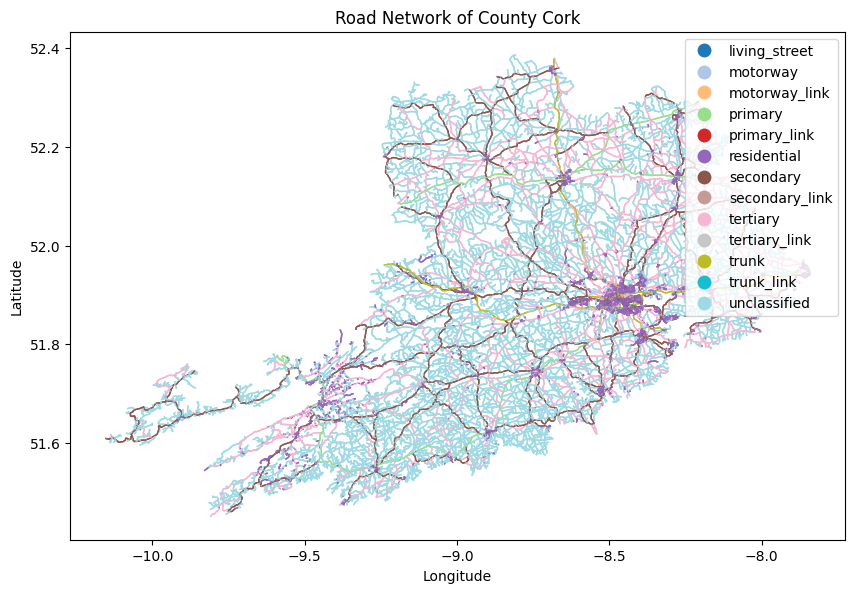

In [23]:
fig, ax = plt.subplots(figsize=(10, 10))
# Plot roads with color by type
gdf_edges.plot(ax=ax, linewidth=1, column='highway_flat', cmap='tab20', legend=True)
plt.title("Road Network of County Cork")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [24]:
# Save cleaned data for further use
gdf_edges.to_file("cork_roads.gpkg", driver="GPKG")
print("Saved roads dataset.")

Saved roads dataset.


HDBSCAN

In [25]:
# Reproject Lon/Lat to meters (Web Mercator EPSG:3857)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

pop_df['X_m'], pop_df['Y_m'] = transformer.transform(pop_df['X'].values, pop_df['Y'].values)

# Prepare features: X_m, Y_m, Z (Density)
features = pop_df[['X_m', 'Y_m', 'Z']].values

# Standardize features to balance spatial vs density influence
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Run HDBSCAN
clusterer = hdbscan.HDBSCAN(min_cluster_size=15, metric='euclidean')
labels = clusterer.fit_predict(features_scaled)

# Attach cluster labels
pop_df['cluster'] = labels

# Summary
print(pop_df['cluster'].value_counts())


/home/sattar/miniconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sattar/miniconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


cluster
 0    25298
-1      276
 1       39
 2       16
Name: count, dtype: int64


/home/sattar/miniconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sattar/miniconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/tmp/ipykernel_5952/3157710967.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pop_df_high['cluster'] = labels_high


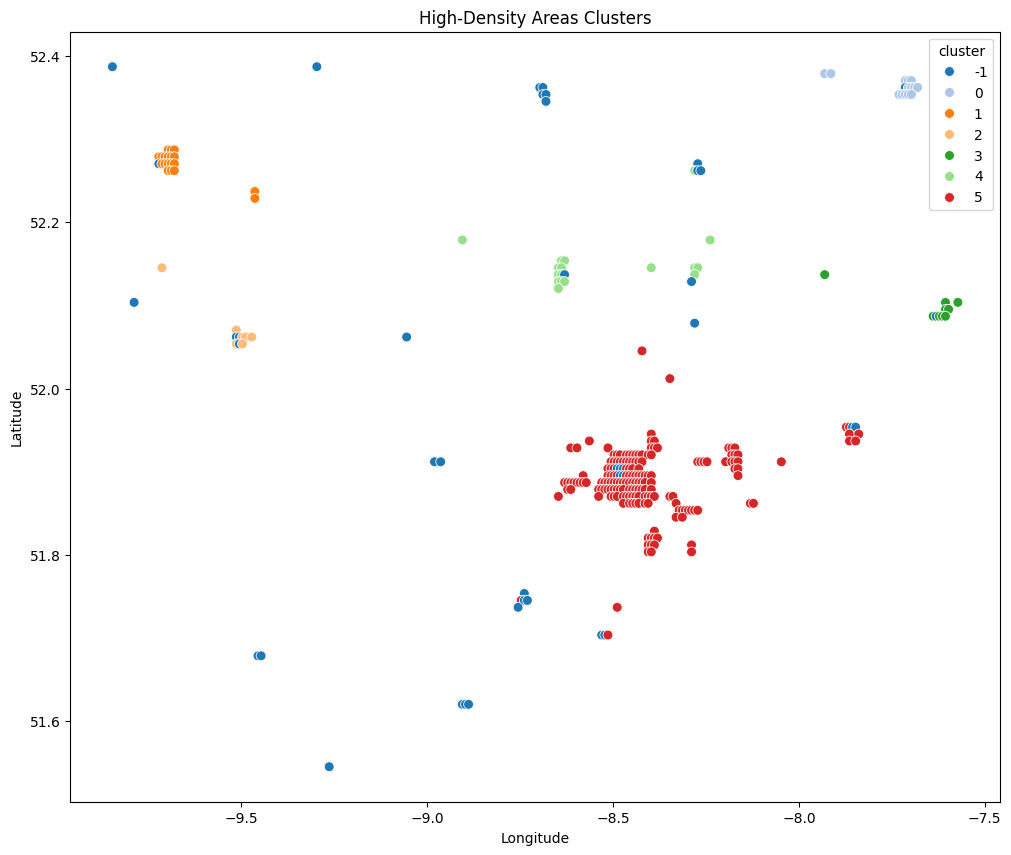

In [26]:
# Filter by density threshold
density_threshold = 1000  # Adjust as needed
pop_df_high = pop_df[pop_df['Z'] > density_threshold]

# Recompute features for high-density only
features_high = pop_df_high[['X_m', 'Y_m', 'Z']].values
features_high_scaled = scaler.fit_transform(features_high)

# Run HDBSCAN again
clusterer_high = hdbscan.HDBSCAN(min_cluster_size=5)
labels_high = clusterer_high.fit_predict(features_high_scaled)

pop_df_high['cluster'] = labels_high

# Visualize high-demand clusters
plt.figure(figsize=(12, 10))
sns.scatterplot(x='X', y='Y', hue='cluster', palette='tab20', data=pop_df_high, s=50, legend='full')
plt.title('High-Density Areas Clusters')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


In [27]:
# Before filtering, keep original index in a new column
pop_df['original_index'] = pop_df.index

# Now filter high-density points
density_threshold = 1000
pop_df_high = pop_df[pop_df['Z'] > density_threshold].copy()

# Run HDBSCAN on high-density points
features_high = pop_df_high[['X_m', 'Y_m', 'Z']].values
features_high_scaled = scaler.fit_transform(features_high)

clusterer_high = hdbscan.HDBSCAN(min_cluster_size=5)
pop_df_high['cluster'] = clusterer_high.fit_predict(features_high_scaled)

# Set all clusters to -1 by default, then assign real clusters
pop_df['cluster'] = -1
pop_df.loc[pop_df_high.index, 'cluster'] = pop_df_high['cluster'].values

# Assign to GeoDataFrame
pop_gdf['cluster'] = pop_df['cluster'].values


/home/sattar/miniconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sattar/miniconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [54]:
import os
import math
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from joblib import Parallel, delayed

import rasterio
from rasterio.transform import Affine
from pyproj import Transformer

import folium
from folium.plugins import HeatMap

# ---- Optional: PuLP for ILP ----
try:
    import pulp
    HAS_PULP = True
except Exception:
    HAS_PULP = False
    warnings.warn("PuLP not available; will use greedy fallback.")


# ==============================
# 1) USER CONFIG (EDIT THESE)
# ==============================

# Bounding box (example: County Cork). Update for your AOI.
MIN_LON, MAX_LON = -10.0, -7.5
MIN_LAT, MAX_LAT = 51.4, 52.4

# Paths
POP_CSV = "Datasets/Ireland_pop/irl_pd_2020_1km_UNadj_ASCII_XYZ.csv"  # columns X(lon), Y(lat), Z(pop)
ELEV_TIF = "cork_srtmgl1.tif"  # elevation raster covering your AOI

# Hex grid size (meters)
HEX_SIZE_M = 2000  # ~2 km centers

# Population cutoff for candidate tower hexes (tune per area)
POP_THRESHOLD = 2000

# Target coverage fraction for ILP (e.g., cover 85% of population within reach)
TARGET_COVERAGE = 0.85

# Safety cap if ILP infeasible: max towers to place greedily
GREEDY_MAX_TOWERS = 120

# Parallelism
N_JOBS = -1  # use all cores


# ==============================
# 2) HELPER MODELS
# ==============================

@dataclass
class ElevationSampler:
    elev: np.ndarray
    transform: Affine
    crs: any
    nodata: float | int | None
    width: int
    height: int
    transformer: Transformer

    def sample(self, lat: float, lon: float) -> float | None:
        try:
            x, y = self.transformer.transform(lon, lat)
            col, row = ~self.transform * (x, y)
            col_i, row_i = int(col), int(row)
            if 0 <= row_i < self.height and 0 <= col_i < self.width:
                val = float(self.elev[row_i, col_i])
                if self.nodata is not None and val == self.nodata:
                    return None
                if np.isnan(val):
                    return None
                return val
            return None
        except Exception:
            return None


def estimate_snr(elev_m: float | None) -> float:
    """Very simple terrain-aware SNR heuristic [0..1]."""
    if elev_m is None:
        return 0.5  # unknown — assume middling value so we don't throw everything away
    if elev_m >= 300:
        return 1.0
    if elev_m >= 150:
        return 0.8
    if elev_m >= 50:
        return 0.6
    return 0.4


def estimate_tower_height(elev_m: float | None) -> float:
    """A gentle scaling of mast height with terrain."""
    if elev_m is None:
        elev_m = 50.0
    return 25.0 + 0.05 * elev_m  # e.g., 25–40 m typical


def estimate_tx_power_dbm(snr: float) -> float:
    """Back-of-envelope: up to +5 dB for excellent conditions."""
    base = 20.0
    return base + 5.0 * snr


def estimate_coverage_km(snr: float, tower_h_m: float) -> float:
    """
    Conservative coverage radius (km) that scales with SNR & mast height.
    This is *not* a radio planning grade model; tweak for your environment.
    """
    # Start with ~1.2 km baseline, scale with snr and log(height)
    return 1.2 * (0.75 + snr) * (1.0 + math.log10(max(10.0, tower_h_m)) / 2.0)


def haversine_km(lat1, lon1, lat2, lon2) -> float:
    R = 6371.0
    p1 = math.radians(lat1)
    p2 = math.radians(lat2)
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat/2.0)**2 + math.cos(p1)*math.cos(p2)*math.sin(dlon/2.0)**2
    c = 2.0*math.atan2(math.sqrt(a), math.sqrt(1.0 - a))
    return R * c


# ==============================
# 3) LOAD POPULATION + HEX GRID
# ==============================

print("Loading population...")
pop_df = pd.read_csv(POP_CSV)
pop_df = pop_df.dropna(subset=["X", "Y", "Z"])

# Filter AOI & positive population
pop_df = pop_df[
    pop_df["X"].between(MIN_LON, MAX_LON)
    & pop_df["Y"].between(MIN_LAT, MAX_LAT)
    & (pop_df["Z"] > 0)
].copy()

if pop_df.empty:
    raise ValueError("No population points in the specified bounding box. Adjust your AOI or input data.")

# GeoDataFrame for population points (WGS84)
pop_gdf = gpd.GeoDataFrame(
    pop_df,
    geometry=gpd.points_from_xy(pop_df["X"], pop_df["Y"]),
    crs="EPSG:4326"
)

# Project to a metric CRS (Web Mercator) to build hexes and do per-cell sums
pop_merc = pop_gdf.to_crs(epsg=3857)
xmin, ymin, xmax, ymax = pop_merc.total_bounds

print("Building hex grid...")
cols = int((xmax - xmin) / HEX_SIZE_M) + 2
rows = int((ymax - ymin) / HEX_SIZE_M) + 2

hexes = []
for col in range(cols):
    for row in range(rows):
        x_off = HEX_SIZE_M * 3/4 * col
        y_off = HEX_SIZE_M * np.sqrt(3) * (row + 0.5 * (col % 2))
        cx = xmin + x_off
        cy = ymin + y_off
        # Regular hex approximated via circle buffer in projected CRS
        hexagon = Point(cx, cy).buffer(HEX_SIZE_M / np.sqrt(3), resolution=6)
        hexes.append(hexagon)

hex_gdf = gpd.GeoDataFrame(geometry=hexes, crs=pop_merc.crs)

# Spatial join + population sum per hex
print("Aggregating population per hex...")
joined = gpd.sjoin(pop_merc, hex_gdf, how="inner", predicate="within")
pop_by_hex = joined.groupby("index_right")["Z"].sum().reset_index()
pop_by_hex.columns = ["hex_id", "population"]

hex_gdf["population"] = 0
hex_gdf.loc[pop_by_hex["hex_id"].values, "population"] = pop_by_hex["population"].values

# Compute centroids in WGS84 for later
hex_centroids = hex_gdf.copy()
hex_centroids["geometry"] = hex_centroids.centroid
hex_centroids = hex_centroids.to_crs(epsg=4326)
hex_centroids["lon"] = hex_centroids.geometry.x
hex_centroids["lat"] = hex_centroids.geometry.y


# ==============================
# 4) ELEVATION (PARALLEL)
# ==============================

print("Preparing elevation sampler...")
with rasterio.open(ELEV_TIF) as src:
    elev_data = src.read(1)
    transform = src.transform
    height, width = elev_data.shape
    nodata = src.nodata
    raster_crs = src.crs

sampler = ElevationSampler(
    elev=elev_data,
    transform=transform,
    crs=raster_crs,
    nodata=nodata,
    width=width,
    height=height,
    transformer=Transformer.from_crs("EPSG:4326", raster_crs, always_xy=True),
)

print("Sampling elevations in parallel...")
coords = list(zip(hex_centroids["lat"].values, hex_centroids["lon"].values))
elevations = Parallel(n_jobs=N_JOBS, prefer="threads")(delayed(sampler.sample)(lat, lon) for lat, lon in coords)
hex_centroids["elevation"] = elevations

# Signal quality & engineering estimates
hex_centroids["snr"] = hex_centroids["elevation"].apply(estimate_snr)
hex_centroids["tower_height"] = hex_centroids["elevation"].apply(estimate_tower_height)
hex_centroids["tx_power_dbm"] = hex_centroids["snr"].apply(estimate_tx_power_dbm)
hex_centroids["coverage_km"] = hex_centroids.apply(
    lambda r: estimate_coverage_km(r["snr"], r["tower_height"]), axis=1
)
hex_centroids["population"] = hex_gdf["population"].values

# Candidate towers: population threshold + reasonable coverage
candidates = hex_centroids[(hex_centroids["population"] >= POP_THRESHOLD) & (hex_centroids["coverage_km"] > 0.5)].copy()

if candidates.empty:
    warnings.warn("No candidate towers found with current thresholds; lowering POP_THRESHOLD by 50% for fallback.")
    thr = max(200, int(POP_THRESHOLD * 0.5))
    candidates = hex_centroids[(hex_centroids["population"] >= thr) & (hex_centroids["coverage_km"] > 0.5)].copy()

# ==============================
# 5) COVERAGE MATRIX
# ==============================
# Build demand points from population (coarse: hex centroids weighted by pop).
demand = hex_centroids[hex_centroids["population"] > 0][["lat", "lon", "population"]].copy()
total_pop = float(demand["population"].sum())
target_pop = TARGET_COVERAGE * total_pop

if candidates.empty:
    print("Still no candidates; map will display population heatmap only.")
    final = pd.DataFrame(columns=["lat","lon","population","elevation","snr","tower_height","tx_power_dbm","coverage_km","type"])
else:
    print("Building coverage matrix (which demand hexes each candidate can cover)...")
    demand_idx = demand.index.to_list()
    cand_idx = candidates.index.to_list()

    # For speed, pre-materialize arrays
    d_lat = demand["lat"].values
    d_lon = demand["lon"].values
    d_pop = demand["population"].values

    c_lat = candidates["lat"].values
    c_lon = candidates["lon"].values
    c_cov = candidates["coverage_km"].values

    covers = []
    for j in range(len(candidates)):
        # vectorized-ish check by looping demand and testing great-circle distance
        covered = []
        r_km = c_cov[j]
        for i in range(len(demand)):
            if haversine_km(c_lat[j], c_lon[j], d_lat[i], d_lon[i]) <= r_km:
                covered.append(demand_idx[i])
        covers.append(set(covered))

    # ==============================
    # 6) ILP or GREEDY
    # ==============================
    def solve_ilp_max_coverage_min_towers(covers, demand, candidates, target_population):
        """
        Choose minimum number of towers such that covered population >= target_population.
        If infeasible, returns None.
        """
        if not HAS_PULP or len(candidates) == 0:
            return None

        # Binary var for tower j
        y = pulp.LpVariable.dicts("tower", list(range(len(candidates))), lowBound=0, upBound=1, cat=pulp.LpBinary)

        # Binary var if demand i is covered
        x = pulp.LpVariable.dicts("cover", list(range(len(demand))), lowBound=0, upBound=1, cat=pulp.LpBinary)

        prob = pulp.LpProblem("MinTowersForCoverage", pulp.LpMinimize)

        # Minimize number of towers
        prob += pulp.lpSum([y[j] for j in range(len(candidates))])

        # Coverage linking: demand i covered only if at least one tower covering it is chosen
        cover_sets = {i: [] for i in range(len(demand))}
        idx_map = {idx:i for i, idx in enumerate(demand.index.to_list())}
        for j in range(len(candidates)):
            for idx in covers[j]:
                i = idx_map[idx]
                cover_sets[i].append(j)

        # If some demand has no possible covering tower, it just can't be covered (x_i can be 0)
        for i in range(len(demand)):
            if cover_sets[i]:
                prob += x[i] <= pulp.lpSum([y[j] for j in cover_sets[i]])
            else:
                prob += x[i] <= 0  # cannot be covered by any tower

        # Achieve target population coverage
        pop_arr = demand["population"].values
        prob += pulp.lpSum([pop_arr[i] * x[i] for i in range(len(demand))]) >= target_population

        # Solve
        solver = pulp.PULP_CBC_CMD(msg=False, timeLimit=120)
        status = prob.solve(solver)

        if pulp.LpStatus[status] != "Optimal" and pulp.LpStatus[status] != "Feasible":
            return None

        chosen = [j for j in range(len(candidates)) if y[j].value() is not None and y[j].value() >= 0.5]
        return chosen

    print("Solving ILP...")
    chosen_idx = solve_ilp_max_coverage_min_towers(covers, demand, candidates, target_pop)

    if chosen_idx is None or len(chosen_idx) == 0:
        print("ILP infeasible or no selection; using greedy fallback.")
        # Greedy: repeatedly pick the tower that adds the most uncovered population
        uncovered = set(demand_idx)
        chosen = []
        for _ in range(GREEDY_MAX_TOWERS):
            best_gain = 0
            best_j = None
            for j in range(len(candidates)):
                gain = sum(demand.loc[list(covers[j] & uncovered), "population"])
                if gain > best_gain:
                    best_gain = gain
                    best_j = j
            if best_j is None or best_gain <= 0:
                break
            chosen.append(best_j)
            # mark covered
            uncovered -= covers[best_j]
            # stop if we hit target coverage
            covered_pop = total_pop - demand.loc[list(uncovered), "population"].sum()
            if covered_pop >= target_pop:
                break
        chosen_idx = chosen

    final = candidates.iloc[chosen_idx].copy() if len(chosen_idx) else pd.DataFrame(columns=candidates.columns)

# Label type (very rough): urban/rural by local hex-pop threshold
if not final.empty:
    # compute local density percentile to label "Urban"
    pop_vals = final["population"].values
    thr = np.percentile(pop_vals, 65) if len(pop_vals) >= 5 else np.mean(pop_vals)
    final["type"] = np.where(final["population"] >= thr, "Urban", "Rural")
else:
    final["type"] = []


# ==============================
# 7) FOLIUM MAP + HEATMAP
# ==============================
center_lat = (MIN_LAT + MAX_LAT) / 2.0
center_lon = (MIN_LON + MAX_LON) / 2.0

m = folium.Map(location=[center_lat, center_lon], zoom_start=8, tiles="OpenStreetMap")

# Population heatmap (thresholded for visibility)
print("Adding population heatmap...")
heat_data = pop_df.loc[pop_df["Z"] > 500, ["Y", "X", "Z"]].values.tolist()
if len(heat_data) > 0:
    HeatMap(heat_data, radius=10, blur=12, max_zoom=12).add_to(m)

# Optional: outline hexes faintly (comment out if heavy)
# hex_outline = hex_gdf.to_crs(epsg=4326)
# folium.GeoJson(
#     hex_outline[["geometry"]],
#     name="Hex Grid",
#     style_function=lambda x: {"weight": 0.3, "color": "#999", "fillOpacity": 0.0},
# ).add_to(m)

# Add tower markers with ADAPTIVE POPUPS (no fixed width!)
print("Adding tower markers...")
for _, row in final.iterrows():
    color = "red" if row["type"] == "Urban" else "blue"

    # Adaptive popup: no fixed width; content wraps naturally
    popup_html = f"""
    <div style="display:inline-block; padding:6px 8px; font: 14px/1.3 'Helvetica Neue', Arial, sans-serif;">
        <div style="margin-bottom:4px; font-weight:700; font-size:15px;">
            {row['type']} Tower
        </div>
        <table style="border-collapse:collapse; font-size:13px;">
            <tr><td style="padding:2px 8px 2px 0; white-space:nowrap;">Population:</td><td style="padding:2px 0;">{int(row['population'])}</td></tr>
            <tr><td style="padding:2px 8px 2px 0; white-space:nowrap;">Elevation:</td><td style="padding:2px 0;">{('%.2f m' % row['elevation']) if pd.notna(row['elevation']) else 'N/A'}</td></tr>
            <tr><td style="padding:2px 8px 2px 0; white-space:nowrap;">SNR score:</td><td style="padding:2px 0;">{row['snr']:.2f}</td></tr>
            <tr><td style="padding:2px 8px 2px 0; white-space:nowrap;">Tower height:</td><td style="padding:2px 0;">{row['tower_height']:.2f} m</td></tr>
            <tr><td style="padding:2px 8px 2px 0; white-space:nowrap;">Tx power:</td><td style="padding:2px 0;">{row['tx_power_dbm']:.2f} dBm</td></tr>
            <tr><td style="padding:2px 8px 2px 0; white-space:nowrap;">Coverage radius:</td><td style="padding:2px 0;">{row['coverage_km']:.2f} km</td></tr>
            <tr><td style="padding:2px 8px 2px 0; white-space:nowrap;">Lat / Lon:</td><td style="padding:2px 0;">{row['lat']:.5f}, {row['lon']:.5f}</td></tr>
        </table>
    </div>
    """

    folium.Marker(
        [row["lat"], row["lon"]],
        popup=folium.Popup(popup_html, max_width="auto"),
        icon=folium.Icon(color=color, icon="signal")
    ).add_to(m)

    # Coverage circle
    folium.Circle(
        [row["lat"], row["lon"]],
        radius=float(row["coverage_km"]) * 1000.0,
        color=color,
        fill=True,
        fill_opacity=0.15,
        weight=2,
    ).add_to(m)

# Layers
folium.LayerControl(collapsed=True).add_to(m)

# Save outputs
m.save("tower_placement_map.html")
final_out = final.copy()
final_out = final_out[["lat","lon","population","elevation","snr","tower_height","tx_power_dbm","coverage_km","type"]]
final_out.to_csv("optimal_towers.csv", index=False)

print("✅ Done.")
print("   - Map: tower_placement_map.html")
print("   - CSV: optimal_towers.csv")


Loading population...
Building hex grid...
Aggregating population per hex...
Preparing elevation sampler...


/tmp/ipykernel_5952/3973976723.py:186: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[13.55741191  9.43306851  7.67735982 ...  5.22358871  5.41578388
 12.73432708]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  hex_gdf.loc[pop_by_hex["hex_id"].values, "population"] = pop_by_hex["population"].values


Sampling elevations in parallel...
Building coverage matrix (which demand hexes each candidate can cover)...
Solving ILP...
ILP infeasible or no selection; using greedy fallback.
Adding population heatmap...
Adding tower markers...
✅ Done.
   - Map: tower_placement_map.html
   - CSV: optimal_towers.csv


In [56]:
import os
import math
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box
from joblib import Parallel, delayed

import rasterio
from rasterio.transform import Affine
from pyproj import Transformer

import folium
from folium.plugins import HeatMap

# ---- Optional deps ----
try:
    import hdbscan
    HAS_HDBSCAN = True
except Exception:
    HAS_HDBSCAN = False
    warnings.warn("HDBSCAN not available; falling back to 'single global cluster' mode.")

try:
    import pulp
    HAS_PULP = True
except Exception:
    HAS_PULP = False
    warnings.warn("PuLP not available; will use greedy fallback for tower selection.")

# ==============================
# 1) USER CONFIG (EDIT THESE)
# ==============================

# Area of Interest (example: County Cork). Make it yours.
MIN_LON, MAX_LON = -10.0, -7.5
MIN_LAT, MAX_LAT =  51.4,  52.4

# Input data
POP_CSV  = "Datasets/Ireland_pop/irl_pd_2020_1km_UNadj_ASCII_XYZ.csv"  # columns: X(lon), Y(lat), Z(pop)
ELEV_TIF = "cork_srtmgl1.tif"  # elevation raster covering your AOI

# Clustering (auto-scaled; tweak caps below)
CLUSTER_MIN_SAMPLES = 5
CLUSTER_MIN_SIZE_FRACTION = 0.002   # ~0.2% of points; min/max caps applied below
CLUSTER_MIN_SIZE_MIN = 15
CLUSTER_MIN_SIZE_MAX = 500

# Hex sizes (meters) and thresholds
HEX_SIZE_M_URBAN = 2000         # ~2 km
HEX_SIZE_M_RURAL = 5000         # coarser for sparse areas
POP_THRESHOLD_URBAN = 2000
POP_THRESHOLD_RURAL = 600       # lower threshold so low density still forms candidates

# Coverage & selection
TARGET_COVERAGE = 0.85          # fraction of population to cover per cluster (applied cluster-wise)
GREEDY_MAX_TOWERS = 200
N_JOBS = -1                     # all cores

# Outputs
OUT_MAP = "tower_placement_hdbscan_map.html"
OUT_CSV = "optimal_towers_hdbscan.csv"

# ==============================
# 2) HELPER MODELS
# ==============================

@dataclass
class ElevationSampler:
    elev: np.ndarray
    transform: Affine
    crs: any
    nodata: float | int | None
    width: int
    height: int
    transformer: Transformer

    def sample(self, lat: float, lon: float) -> float | None:
        try:
            x, y = self.transformer.transform(lon, lat)
            col, row = ~self.transform * (x, y)
            col_i, row_i = int(col), int(row)
            if 0 <= row_i < self.height and 0 <= col_i < self.width:
                val = float(self.elev[row_i, col_i])
                if self.nodata is not None and val == self.nodata:
                    return None
                if np.isnan(val):
                    return None
                return val
            return None
        except Exception:
            return None

def estimate_snr(elev_m: float | None) -> float:
    if elev_m is None:
        return 0.5
    if elev_m >= 300:
        return 1.0
    if elev_m >= 150:
        return 0.8
    if elev_m >= 50:
        return 0.6
    return 0.4

def estimate_tower_height(elev_m: float | None) -> float:
    if elev_m is None:
        elev_m = 50.0
    return 25.0 + 0.05 * elev_m  # 25–40 m typical range

def estimate_tx_power_dbm(snr: float) -> float:
    return 20.0 + 5.0 * snr

def estimate_coverage_km(snr: float, tower_h_m: float) -> float:
    # conservative radius scaling with SNR and mast height
    return 1.2 * (0.75 + snr) * (1.0 + math.log10(max(10.0, tower_h_m)) / 2.0)

def haversine_km(lat1, lon1, lat2, lon2) -> float:
    R = 6371.0
    p1 = math.radians(lat1)
    p2 = math.radians(lat2)
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat/2.0)**2 + math.cos(p1)*math.cos(p2)*math.sin(dlon/2.0)**2
    c = 2.0 * math.atan2(math.sqrt(a), math.sqrt(1.0 - a))
    return R * c

# ==============================
# 3) LOAD POPULATION
# ==============================

print("Loading population…")
pop_df = pd.read_csv(POP_CSV).dropna(subset=["X","Y","Z"])
pop_df = pop_df[
    pop_df["X"].between(MIN_LON, MAX_LON)
    & pop_df["Y"].between(MIN_LAT, MAX_LAT)
    & (pop_df["Z"] > 0)
].copy()

if pop_df.empty:
    raise ValueError("No population points in AOI. Adjust bounding box or input data.")

pop_gdf = gpd.GeoDataFrame(
    pop_df,
    geometry=gpd.points_from_xy(pop_df["X"], pop_df["Y"]),
    crs="EPSG:4326"
)

# project to meters for clustering
pop_m = pop_gdf.to_crs(epsg=3857)
pop_m["x"] = pop_m.geometry.x
pop_m["y"] = pop_m.geometry.y

# ==============================
# 4) HDBSCAN CLUSTERING
# ==============================
import inspect

if HAS_HDBSCAN:
    n_pts = len(pop_m)
    min_cluster_size = int(np.clip(int(CLUSTER_MIN_SIZE_FRACTION * n_pts),
                                   CLUSTER_MIN_SIZE_MIN, CLUSTER_MIN_SIZE_MAX))
    print(f"Running HDBSCAN… (min_cluster_size={min_cluster_size}, min_samples={CLUSTER_MIN_SAMPLES})")
    X = pop_m[["x", "y"]].values
    weights = pop_m["Z"].values

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=CLUSTER_MIN_SAMPLES,
        cluster_selection_epsilon=0.0,
        core_dist_n_jobs=N_JOBS
    )

    # Check if sample_weight is accepted
    if "sample_weight" in inspect.signature(clusterer.fit_predict).parameters:
        labels = clusterer.fit_predict(X, sample_weight=weights)
    else:
        labels = clusterer.fit_predict(X)

    pop_gdf["cluster"] = labels
else:
    print("HDBSCAN missing: treating AOI as a single cluster (0).")
    pop_gdf["cluster"] = 0


# ==============================
# 5) ELEVATION SAMPLER
# ==============================

print("Preparing elevation…")
with rasterio.open(ELEV_TIF) as src:
    elev_data = src.read(1)
    transform = src.transform
    height, width = elev_data.shape
    nodata = src.nodata
    raster_crs = src.crs

sampler = ElevationSampler(
    elev=elev_data,
    transform=transform,
    crs=raster_crs,
    nodata=nodata,
    width=width,
    height=height,
    transformer=Transformer.from_crs("EPSG:4326", raster_crs, always_xy=True),
)

# ==============================
# 6) PER-CLUSTER OPTIMIZATION
# ==============================

def build_hex_aggregate(pop_subset: gpd.GeoDataFrame, hex_size_m: int) -> gpd.GeoDataFrame:
    """Build a hex grid over subset (buffered bbox) and aggregate population per cell."""
    if pop_subset.empty:
        return gpd.GeoDataFrame(columns=["geometry","population"], geometry="geometry", crs="EPSG:3857")

    subset_m = pop_subset.to_crs(epsg=3857)
    xmin, ymin, xmax, ymax = subset_m.total_bounds
    # pad bbox by one hex to avoid edge bleed
    pad = hex_size_m * 1.5
    xmin -= pad; ymin -= pad; xmax += pad; ymax += pad

    cols = int((xmax - xmin) / hex_size_m) + 2
    rows = int((ymax - ymin) / hex_size_m) + 2

    hexes = []
    for c in range(cols):
        for r in range(rows):
            x_off = hex_size_m * 3/4 * c
            y_off = hex_size_m * np.sqrt(3) * (r + 0.5 * (c % 2))
            cx = xmin + x_off
            cy = ymin + y_off
            hexagon = Point(cx, cy).buffer(hex_size_m / np.sqrt(3), resolution=6)
            hexes.append(hexagon)

    hex_gdf = gpd.GeoDataFrame(geometry=hexes, crs="EPSG:3857")

    # spatial join and sum
    joined = gpd.sjoin(
        subset_m[["Z","geometry"]],
        hex_gdf, how="inner", predicate="within"
    )
    agg = joined.groupby("index_right")["Z"].sum().reset_index()
    hex_gdf["population"] = 0
    hex_gdf.loc[agg["index_right"].values, "population"] = agg["Z"].values

    return hex_gdf

def build_candidates(hex_gdf_3857: gpd.GeoDataFrame, pop_threshold: int) -> gpd.GeoDataFrame:
    """Compute centroids in WGS84 + radio/elevation features for cells above pop threshold."""
    if hex_gdf_3857.empty:
        return gpd.GeoDataFrame(columns=["lat","lon","population","elevation","snr","tower_height","tx_power_dbm","coverage_km"],
                                geometry=[], crs="EPSG:4326")
    cents = hex_gdf_3857.copy()
    cents["geometry"] = cents.centroid
    cents = cents.to_crs(epsg=4326)
    cents["lat"] = cents.geometry.y
    cents["lon"] = cents.geometry.x

    # elevation (parallel)
    coords = list(zip(cents["lat"].values, cents["lon"].values))
    elevations = Parallel(n_jobs=N_JOBS, prefer="threads")(delayed(sampler.sample)(lat, lon) for lat, lon in coords)
    cents["elevation"] = elevations
    cents["snr"] = cents["elevation"].apply(estimate_snr)
    cents["tower_height"] = cents["elevation"].apply(estimate_tower_height)
    cents["tx_power_dbm"] = cents["snr"].apply(estimate_tx_power_dbm)
    cents["coverage_km"] = cents.apply(lambda r: estimate_coverage_km(r["snr"], r["tower_height"]), axis=1)

    # keep candidates above threshold and with meaningful radius
    cand = cents[(cents["population"] >= pop_threshold) & (cents["coverage_km"] > 0.5)].copy()
    return cand

def build_demand(hex_gdf_3857: gpd.GeoDataFrame) -> pd.DataFrame:
    """Demand = centroids of all populated hexes (WGS84) with weights."""
    if hex_gdf_3857.empty:
        return pd.DataFrame(columns=["lat","lon","population"])
    d = hex_gdf_3857[hex_gdf_3857["population"] > 0].copy()
    d["geometry"] = d.centroid
    d = d.to_crs(epsg=4326)
    return pd.DataFrame({
        "lat": d.geometry.y.values,
        "lon": d.geometry.x.values,
        "population": d["population"].values
    })

def build_covers(demand: pd.DataFrame, candidates: gpd.GeoDataFrame):
    """List of sets: for each candidate j, indices of demand rows it covers."""
    covers = []
    d_idx = demand.index.to_list()
    d_lat = demand["lat"].values
    d_lon = demand["lon"].values
    c_lat = candidates["lat"].values
    c_lon = candidates["lon"].values
    c_cov = candidates["coverage_km"].values

    for j in range(len(candidates)):
        covered = []
        r_km = c_cov[j]
        for i in range(len(demand)):
            if haversine_km(c_lat[j], c_lon[j], d_lat[i], d_lon[i]) <= r_km:
                covered.append(d_idx[i])
        covers.append(set(covered))
    return covers

def solve_ilp_min_towers_for_target(demand: pd.DataFrame, candidates: gpd.GeoDataFrame, covers, target_fraction: float):
    """Minimize number of towers to cover at least target_fraction of demand population."""
    if not HAS_PULP or len(candidates) == 0 or demand.empty:
        return None

    total_pop = float(demand["population"].sum())
    target_pop = target_fraction * total_pop

    y = pulp.LpVariable.dicts("tower", list(range(len(candidates))), 0, 1, cat=pulp.LpBinary)
    x = pulp.LpVariable.dicts("cover", list(range(len(demand))), 0, 1, cat=pulp.LpBinary)

    prob = pulp.LpProblem("MinTowersPerCluster", pulp.LpMinimize)
    prob += pulp.lpSum([y[j] for j in range(len(candidates))])

    # demand index mapping
    idx_map = {idx:i for i, idx in enumerate(demand.index.to_list())}
    cover_sets = {i: [] for i in range(len(demand))}
    for j in range(len(candidates)):
        for idx in covers[j]:
            i = idx_map[idx]
            cover_sets[i].append(j)

    for i in range(len(demand)):
        if cover_sets[i]:
            prob += x[i] <= pulp.lpSum([y[j] for j in cover_sets[i]])
        else:
            prob += x[i] <= 0

    pop_arr = demand["population"].values
    prob += pulp.lpSum([pop_arr[i] * x[i] for i in range(len(demand))]) >= target_pop

    solver = pulp.PULP_CBC_CMD(msg=False, timeLimit=120)
    status = prob.solve(solver)
    if pulp.LpStatus[status] not in ("Optimal","Feasible"):
        return None

    chosen = [j for j in range(len(candidates)) if y[j].value() is not None and y[j].value() >= 0.5]
    return chosen

def greedy_select(demand: pd.DataFrame, candidates: gpd.GeoDataFrame, covers, target_fraction: float, max_towers: int):
    total_pop = float(demand["population"].sum())
    target_pop = target_fraction * total_pop
    d_idx = set(demand.index.to_list())
    uncovered = set(d_idx)
    chosen = []

    for _ in range(max_towers):
        best_gain = 0
        best_j = None
        for j in range(len(candidates)):
            gain = sum(demand.loc[list(covers[j] & uncovered), "population"])
            if gain > best_gain:
                best_gain = gain
                best_j = j
        if best_j is None or best_gain <= 0:
            break
        chosen.append(best_j)
        uncovered -= covers[best_j]
        covered_pop = total_pop - demand.loc[list(uncovered), "population"].sum()
        if covered_pop >= target_pop:
            break
    return chosen

def optimize_cluster(cluster_id: int, pop_cluster_gdf: gpd.GeoDataFrame) -> pd.DataFrame:
    """End-to-end pipeline for one cluster: hex aggregate -> candidates -> covers -> ILP/greedy."""
    is_rural = (cluster_id == -1)  # -1 is HDBSCAN noise
    hex_size = HEX_SIZE_M_RURAL if is_rural else HEX_SIZE_M_URBAN
    pop_thr  = POP_THRESHOLD_RURAL if is_rural else POP_THRESHOLD_URBAN

    hex_3857 = build_hex_aggregate(pop_cluster_gdf, hex_size)
    if hex_3857.empty:
        return pd.DataFrame(columns=["lat","lon","population","elevation","snr","tower_height","tx_power_dbm","coverage_km","type","cluster"])

    candidates = build_candidates(hex_3857, pop_thr)

    # if too strict, relax for very sparse clusters
    if candidates.empty and is_rural:
        relaxed = max(100, int(pop_thr * 0.5))
        candidates = build_candidates(hex_3857, relaxed)

    demand = build_demand(hex_3857)
    if candidates.empty or demand.empty:
        # Nothing to place
        return pd.DataFrame(columns=["lat","lon","population","elevation","snr","tower_height","tx_power_dbm","coverage_km","type","cluster"])

    covers = build_covers(demand, candidates)
    chosen_idx = solve_ilp_min_towers_for_target(demand, candidates, covers, TARGET_COVERAGE)
    if (chosen_idx is None) or (len(chosen_idx) == 0):
        chosen_idx = greedy_select(demand, candidates, covers, TARGET_COVERAGE, GREEDY_MAX_TOWERS)

    if len(chosen_idx) == 0:
        return pd.DataFrame(columns=["lat","lon","population","elevation","snr","tower_height","tx_power_dbm","coverage_km","type","cluster"])

    final = candidates.iloc[chosen_idx].copy()
    # Urban/rural label within the cluster by percentile
    pop_vals = final["population"].values
    thr = np.percentile(pop_vals, 65) if len(pop_vals) >= 5 else np.mean(pop_vals)
    final["type"] = np.where(final["population"] >= thr, "Urban", "Rural")
    final["cluster"] = cluster_id
    return final[["lat","lon","population","elevation","snr","tower_height","tx_power_dbm","coverage_km","type","cluster"]]

# Run per cluster
all_clusters = sorted(pop_gdf["cluster"].unique().tolist())
results = []
for cid in all_clusters:
    subset = pop_gdf[pop_gdf["cluster"] == cid]
    print(f"Optimizing cluster {cid} (points={len(subset)})…")
    res = optimize_cluster(cid, subset)
    if not res.empty:
        results.append(res)

if len(results):
    final_all = pd.concat(results, ignore_index=True)
else:
    # Safety: if everything failed (e.g., missing HDBSCAN + invalid elev), try single-bucket global
    print("No per-cluster result; running single global optimization as fallback.")
    pop_gdf["cluster"] = 0
    res = optimize_cluster(0, pop_gdf)
    final_all = res if not res.empty else pd.DataFrame(columns=["lat","lon","population","elevation","snr","tower_height","tx_power_dbm","coverage_km","type","cluster"])

# ==============================
# 7) MAP & CSV
# ==============================

center_lat = (MIN_LAT + MAX_LAT) / 2.0
center_lon = (MIN_LON + MAX_LON) / 2.0
m = folium.Map(location=[center_lat, center_lon], zoom_start=8, tiles="OpenStreetMap")

# Population heatmap (clip for visibility)
print("Adding population heatmap…")
heat = pop_df.loc[pop_df["Z"] > 500, ["Y","X","Z"]].values.tolist()
if len(heat) > 0:
    HeatMap(heat, radius=10, blur=12, max_zoom=12).add_to(m)

# Towers
print("Adding tower markers…")
if not final_all.empty:
    # color by type; add cluster id in popup
    for _, row in final_all.iterrows():
        color = "red" if row["type"] == "Urban" else "blue"
        popup_html = f"""
        <div style="display:inline-block; padding:6px 8px; font: 14px/1.3 'Helvetica Neue', Arial, sans-serif;">
            <div style="margin-bottom:4px; font-weight:700; font-size:15px;">
                {row['type']} Tower  •  Cluster {row['cluster']}
            </div>
            <table style="border-collapse:collapse; font-size:13px;">
                <tr><td style="padding:2px 8px 2px 0; white-space:nowrap;">Population:</td><td style="padding:2px 0;">{int(row['population'])}</td></tr>
                <tr><td style="padding:2px 8px 2px 0; white-space:nowrap;">Elevation:</td><td style="padding:2px 0;">{('%.2f m' % row['elevation']) if pd.notna(row['elevation']) else 'N/A'}</td></tr>
                <tr><td style="padding:2px 8px 2px 0; white-space:nowrap;">SNR score:</td><td style="padding:2px 0;">{row['snr']:.2f}</td></tr>
                <tr><td style="padding:2px 8px 2px 0; white-space:nowrap;">Tower height:</td><td style="padding:2px 0;">{row['tower_height']:.2f} m</td></tr>
                <tr><td style="padding:2px 8px 2px 0; white-space:nowrap;">Tx power:</td><td style="padding:2px 0;">{row['tx_power_dbm']:.2f} dBm</td></tr>
                <tr><td style="padding:2px 8px 2px 0; white-space:nowrap;">Coverage radius:</td><td style="padding:2px 0;">{row['coverage_km']:.2f} km</td></tr>
                <tr><td style="padding:2px 8px 2px 0; white-space:nowrap;">Lat / Lon:</td><td style="padding:2px 0;">{row['lat']:.5f}, {row['lon']:.5f}</td></tr>
            </table>
        </div>
        """
        folium.Marker(
            [row["lat"], row["lon"]],
            popup=folium.Popup(popup_html, max_width="auto"),
            icon=folium.Icon(color=color, icon="signal")
        ).add_to(m)

        # coverage circle
        folium.Circle(
            [row["lat"], row["lon"]],
            radius=float(row["coverage_km"]) * 1000.0,
            color=color,
            fill=True,
            fill_opacity=0.15,
            weight=2,
        ).add_to(m)

# Layers
folium.LayerControl(collapsed=True).add_to(m)

# Save
m.save(OUT_MAP)
final_all.to_csv(OUT_CSV, index=False)

print("✅ Done.")
print(f"   - Map: {OUT_MAP}")
print(f"   - CSV: {OUT_CSV}")


Loading population…
Running HDBSCAN… (min_cluster_size=51, min_samples=5)


/home/sattar/miniconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sattar/miniconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Preparing elevation…
Optimizing cluster -1 (points=18358)…


/tmp/ipykernel_5952/400034925.py:247: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.08708286e+01 2.05569906e+01 9.80611503e-01 1.91361263e+01
 1.97221541e+01 3.02848901e+01 1.61500868e+02 1.58639600e+02
 2.61346463e+01 5.38690754e+02 1.76121403e+02 2.71390800e+01
 1.52711233e+01 3.20094902e+01 2.92332670e+01 1.48730559e+02
 1.38148179e+02 3.38260632e+01 6.41062102e+01 2.40493219e+02
 7.56209636e+00 1.93750639e+01 2.46954621e+01 3.24447898e+01
 8.95664894e+02 2.07044555e+02 1.54571400e+02 1.16831529e+02
 3.39592724e+02 9.27871189e+01 8.18439605e+01 2.26597064e+01
 3.58068187e+01 4.03602483e+01 5.47720532e+01 5.58286329e+02
 9.71299131e+02 1.32508637e+02 6.84394318e+02 2.19598328e+02
 6.86014328e+01 5.88059158e+01 2.33087349e+01 4.91615057e+00
 3.60410976e+00 1.10683887e+01 2.73852493e+01 4.91570654e+01
 9.63286297e+01 9.17043666e+01 1.08429747e+03 2.24388472e+02
 5.83647783e+01 2.09042325e+02 1.7660783

Optimizing cluster 0 (points=242)…
Optimizing cluster 1 (points=6802)…


/tmp/ipykernel_5952/400034925.py:247: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 25.85828876  18.09901094   3.0367521    2.60350746   1.63272244
  23.68514538   5.63698602   3.94374001   3.24848408   2.86064959
  35.38277817  10.40766764   3.80529964   4.08841288   3.52055848
  33.92740154   5.78992224  28.28656197   4.35906446   3.08875406
  41.41966248   4.21308827   5.37892151   5.95861566   5.91646647
   9.59426236   8.26367736   6.6589843   10.72865582   4.96579981
  56.21747828   8.15618384  50.0956068    7.07341766  29.07143784
  74.38492465   5.6337496   11.30794954  32.45183921 207.52087641
   6.14510727  85.94277573  11.69253826   7.99142766   4.77900875
  35.84784031  60.32912016   7.74886608  12.69217181  11.26524687
  15.75307846  10.41243553   8.41963482  11.61737776  10.14189196
   9.90995979  35.83173037  17.52561164   8.35229433  42.58935261
   9.81939459  13.72060275]' has dtype in

Optimizing cluster 2 (points=227)…
Adding population heatmap…
Adding tower markers…


/tmp/ipykernel_5952/400034925.py:247: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[  85.88403893   85.88637257  272.86430359  607.63812256  115.10324097
  800.61808777  185.82954407  642.40119839  274.78526688 1125.25115585
   50.58998871   26.03162003   41.85817504   50.29183388 1311.81091309
   92.99471283   94.39722919   79.74296951  451.38383102  122.24756813
   39.620121    184.64077377   37.9088068   339.74110413  128.24175262
   59.41945839   51.40334892   46.40876961 1079.38537598   28.5617485
   76.96797466   44.35215282   50.24978352   20.05584335   53.44532204
   35.86129665   36.70926285  290.45837021   89.23778915   55.87791729
   43.60066891 3407.29638672   63.79805756   30.3803091    36.96959019
  338.17209244   26.62213659   83.88042831   48.50857353   33.50378704
   86.36757851   86.32914925   75.87289047   28.98956108  179.16730881
   39.60700417  115.56210709   42.9632225    69.36598

✅ Done.
   - Map: tower_placement_hdbscan_map.html
   - CSV: optimal_towers_hdbscan.csv


In [ ]:
# -*- coding: utf-8 -*-
"""
Tower placement with HDBSCAN + path-loss coverage + water masking + redundancy pruning.

Author: You & Bishop
"""

import os
import math
import warnings
import inspect
from dataclasses import dataclass

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from shapely.ops import unary_union
from joblib import Parallel, delayed

import rasterio
from rasterio.transform import Affine
from pyproj import Transformer

import folium
from folium.plugins import HeatMap

# ---------- Optional deps ----------
try:
    import hdbscan
    HAS_HDBSCAN = True
except Exception:
    HAS_HDBSCAN = False
    warnings.warn("HDBSCAN not available; falling back to single-cluster mode.")

try:
    import pulp
    HAS_PULP = True
except Exception:
    HAS_PULP = False
    warnings.warn("PuLP not available; greedy selection will be used.")


# ==============================
# 1) USER CONFIG
# ==============================

# Area of Interest
MIN_LON, MAX_LON = -10.0, -7.5
MIN_LAT, MAX_LAT =  51.4,  52.4

# Inputs
POP_CSV   = "Datasets/Ireland_pop/irl_pd_2020_1km_UNadj_ASCII_XYZ.csv"  # columns: X(lon), Y(lat), Z(pop)
ELEV_TIF  = "cork_srtmgl1.tif"   # DEM covering AOI
WATER_SHP = "water_polygons.shp" # polygon water mask (optional). If missing, water masking is skipped.

# (Optional) existing towers to avoid duplicating (point layer)
EXISTING_TOWERS = None           # e.g., "comreg_cells.gpkg"
EXISTING_BUFFER_M = 300          # skip new sites within this distance of an existing site

# Clustering
CLUSTER_MIN_SAMPLES = 5
CLUSTER_MIN_SIZE_FRACTION = 0.002
CLUSTER_MIN_SIZE_MIN = 15
CLUSTER_MIN_SIZE_MAX = 600

# Hex sizes & thresholds (meters / people)
HEX_SIZE_M_URBAN = 2000
HEX_SIZE_M_RURAL = 5000
URBAN_POP_PCTL   = 70       # candidate threshold = pct of populated-hex pop in cluster (urban)
RURAL_POP_PCTL   = 50       # candidate threshold percentile for noise/rural
MIN_POP_FLOOR_URBAN = 1200  # floor to avoid tiny thresholds
MIN_POP_FLOOR_RURAL = 300

# Radio / link budget
FC_MHZ_DEFAULT = 1800.0     # path-loss model defaults to COST-231 up to ~2000 MHz
BAND_FALLBACK_LOS = True    # for fc > 2000 MHz use simple LOS model
UE_HEIGHT_M = 1.5
TX_BASE_DBM = 20.0          # baseline Tx power (will scale a bit with SNR proxy)
NOISE_FLOOR_DBM = -100.0    # rough wideband noise floor used to compute SNR proxy
RX_THRESH_DBM = -95.0       # minimum received power considered "covered"
MISC_LOSS_DB = 10.0         # feeder/building/penetration generic loss

# Selection goals
TARGET_COVERAGE = 0.85      # per-cluster population fraction to cover
ALPHA_TOWER = 1.0           # cost weight (minimize number of towers)
GAMMA_QUALITY = 1e-6        # tiny weight to favor high-quality coverage (linear term)
GREEDY_MAX_TOWERS = 250
N_JOBS = -1

# Redundancy pruning
MIN_UNIQUE_POP = 200        # drop towers adding less than this unique population
MIN_EFFICIENCY = 0.05       # drop towers whose unique_pop / total_pop_covered < 5%

# Outputs
OUT_MAP = "tower_placement_hdbscan_pathloss_map.html"
OUT_CSV = "optimal_towers_hdbscan_pathloss.csv"


# ==============================
# 2) HELPERS
# ==============================

@dataclass
class ElevationSampler:
    elev: np.ndarray
    transform: Affine
    crs: any
    nodata: float | int | None
    width: int
    height: int
    transformer: Transformer

    def sample(self, lat: float, lon: float) -> float | None:
        try:
            x, y = self.transformer.transform(lon, lat)
            col, row = ~self.transform * (x, y)
            col_i, row_i = int(col), int(row)
            if 0 <= row_i < self.height and 0 <= col_i < self.width:
                val = float(self.elev[row_i, col_i])
                if (self.nodata is not None and val == self.nodata) or np.isnan(val):
                    return None
                return val
            return None
        except Exception:
            return None


def estimate_tx_power_dbm(snr_proxy: float) -> float:
    # small boost with local quality (0..1)
    return TX_BASE_DBM + 5.0 * np.clip(snr_proxy, 0.0, 1.0)


def coverage_circle_km_from_height_quality(tower_h_m: float, qual: float) -> float:
    # used only for initial candidate screening; actual coverage uses path loss
    return 1.2 * (0.75 + qual) * (1.0 + math.log10(max(10.0, tower_h_m)) / 2.0)


def haversine_km(lat1, lon1, lat2, lon2) -> float:
    R = 6371.0
    p1 = math.radians(lat1)
    p2 = math.radians(lat2)
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat/2.0)**2 + math.cos(p1)*math.cos(p2)*math.sin(dlon/2.0)**2
    c = 2.0 * math.atan2(math.sqrt(a), math.sqrt(1.0 - a))
    return R * c


# --- Simple terrain -> SNR proxy (0..1). We’ll still use full link budget later.
def snr_proxy_from_elev(elev_m: float | None) -> float:
    if elev_m is None:
        return 0.5
    if elev_m >= 300: return 1.0
    if elev_m >= 150: return 0.8
    if elev_m >= 50:  return 0.6
    return 0.4


# --- Path loss models ---
def path_loss_cost231_hata(d_km: float, fc_mhz: float, hb_m: float, hm_m: float, env="urban") -> float:
    """
    COST-231 Hata (valid ~1500–2000 MHz). For 900 MHz classic Hata is close.
    env in {"urban","suburban","rural"} affects correction term.
    """
    if d_km <= 0:
        d_km = 0.001
    # Mobile correction
    a_hm = (1.1 * math.log10(fc_mhz) - 0.7) * hm_m - (1.56 * math.log10(fc_mhz) - 0.8)
    L = 46.3 + 33.9 * math.log10(fc_mhz) - 13.82 * math.log10(hb_m) - a_hm \
        + (44.9 - 6.55 * math.log10(hb_m)) * math.log10(d_km) + 3.0  # 3 dB metropolitan correction
    if env == "suburban":
        L -= 2.0
    elif env == "rural":
        L -= 4.0
    return L


def path_loss_simple_los(d_km: float, fc_mhz: float) -> float:
    """
    Simple 3GPP-style LOS: PL = 32.4 + 21*log10(d) + 20*log10(fc_GHz)
    """
    if d_km <= 0:
        d_km = 0.001
    return 32.4 + 21.0 * math.log10(d_km) + 20.0 * math.log10(fc_mhz / 1000.0)


def link_budget_pr_dbm(d_km: float, fc_mhz: float, hb_m: float, hm_m: float, env: str,
                       tx_dbm: float, misc_loss_db: float, allow_los_fallback=True) -> float:
    if fc_mhz <= 2000.0:
        pl = path_loss_cost231_hata(d_km, fc_mhz, hb_m, hm_m, env)
    else:
        if allow_los_fallback:
            pl = path_loss_simple_los(d_km, fc_mhz)
        else:
            pl = path_loss_cost231_hata(d_km, min(2000.0, fc_mhz), hb_m, hm_m, env)
    return tx_dbm - pl - misc_loss_db


# ==============================
# 3) LOAD DATA
# ==============================

print("Loading population…")
pop = pd.read_csv(POP_CSV).dropna(subset=["X","Y","Z"])
pop = pop[
    pop["X"].between(MIN_LON, MAX_LON)
    & pop["Y"].between(MIN_LAT, MAX_LAT)
    & (pop["Z"] > 0)
].copy()
if pop.empty:
    raise ValueError("No population points in AOI.")

pop_gdf = gpd.GeoDataFrame(pop, geometry=gpd.points_from_xy(pop["X"], pop["Y"]), crs="EPSG:4326")
pop_m = pop_gdf.to_crs(epsg=3857)
pop_m["x"] = pop_m.geometry.x
pop_m["y"] = pop_m.geometry.y

# Water mask (optional)
water_union = None
if WATER_SHP and os.path.exists(WATER_SHP):
    try:
        water = gpd.read_file(WATER_SHP)
        if water.crs is None:
            water = water.set_crs("EPSG:4326", allow_override=True)
        water = water.to_crs(pop_gdf.crs)
        water_union = unary_union(water.geometry.values)
        print("Water polygons loaded; masking enabled.")
    except Exception as e:
        warnings.warn(f"Failed to read water polygons: {e}")
else:
    print("No water polygons file; skipping water masking.")

# Existing towers (optional)
existing_union = None
if EXISTING_TOWERS and os.path.exists(EXISTING_TOWERS):
    try:
        ex = gpd.read_file(EXISTING_TOWERS)
        if ex.crs is None:
            ex = ex.set_crs("EPSG:4326", allow_override=True)
        ex_m = ex.to_crs(epsg=3857)
        existing_union = unary_union(ex_m.geometry.buffer(EXISTING_BUFFER_M))
        print("Existing towers loaded; avoidance buffer enabled.")
    except Exception as e:
        warnings.warn(f"Failed to read existing towers: {e}")

# DEM
print("Preparing elevation…")
with rasterio.open(ELEV_TIF) as src:
    elev_data = src.read(1)
    transform = src.transform
    H, W = elev_data.shape
    nodata = src.nodata
    raster_crs = src.crs

sampler = ElevationSampler(
    elev=elev_data,
    transform=transform,
    crs=raster_crs,
    nodata=nodata,
    width=W,
    height=H,
    transformer=Transformer.from_crs("EPSG:4326", raster_crs, always_xy=True),
)

# ==============================
# 4) HDBSCAN
# ==============================

if HAS_HDBSCAN:
    n_pts = len(pop_m)
    min_cluster_size = int(np.clip(int(CLUSTER_MIN_SIZE_FRACTION * n_pts),
                                   CLUSTER_MIN_SIZE_MIN, CLUSTER_MIN_SIZE_MAX))
    print(f"HDBSCAN… (min_cluster_size={min_cluster_size}, min_samples={CLUSTER_MIN_SAMPLES})")
    Xc = pop_m[["x","y"]].values
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=CLUSTER_MIN_SAMPLES,
        core_dist_n_jobs=N_JOBS
    )
    if "sample_weight" in inspect.signature(clusterer.fit_predict).parameters:
        labels = clusterer.fit_predict(Xc, sample_weight=pop_m["Z"].values)
    else:
        labels = clusterer.fit_predict(Xc)
    pop_gdf["cluster"] = labels
else:
    print("HDBSCAN not present; single cluster = 0")
    pop_gdf["cluster"] = 0


# ==============================
# 5) UTIL FUNCS FOR PIPELINE
# ==============================

def build_hex_aggregate(pop_subset_gdf: gpd.GeoDataFrame, hex_size_m: int) -> gpd.GeoDataFrame:
    if pop_subset_gdf.empty:
        return gpd.GeoDataFrame(columns=["geometry","population"], geometry="geometry", crs="EPSG:3857")
    subset_m = pop_subset_gdf.to_crs(epsg=3857)
    xmin,ymin,xmax,ymax = subset_m.total_bounds
    pad = hex_size_m * 1.5
    xmin -= pad; ymin -= pad; xmax += pad; ymax += pad

    cols = int((xmax - xmin) / hex_size_m) + 2
    rows = int((ymax - ymin) / hex_size_m) + 2

    hexes = []
    for c in range(cols):
        for r in range(rows):
            x_off = hex_size_m * 3/4 * c
            y_off = hex_size_m * np.sqrt(3) * (r + 0.5*(c % 2))
            cx = xmin + x_off
            cy = ymin + y_off
            hexagon = Point(cx, cy).buffer(hex_size_m / np.sqrt(3), resolution=6)
            hexes.append(hexagon)

    hex_g = gpd.GeoDataFrame(geometry=hexes, crs="EPSG:3857")

    joined = gpd.sjoin(subset_m[["Z","geometry"]], hex_g, how="inner", predicate="within")
    agg = joined.groupby("index_right")["Z"].sum().reset_index()
    hex_g["population"] = 0
    hex_g.loc[agg["index_right"].values, "population"] = agg["Z"].values

    # Remove water hexes (demand) if all/most centroid in water
    if water_union is not None:
        cents = hex_g.copy()
        cents["geometry"] = cents.centroid
        cents = cents.to_crs(pop_gdf.crs)
        mask = cents.geometry.apply(lambda p: water_union.contains(p))
        # Set population to 0 for water-centroid cells
        hex_g.loc[mask.values, "population"] = 0

    return hex_g


def make_candidates(hex_gdf_3857: gpd.GeoDataFrame, pop_threshold: int,
                    cluster_env: str, cluster_id: int) -> gpd.GeoDataFrame:
    if hex_gdf_3857.empty:
        return gpd.GeoDataFrame(columns=["lat","lon","population","elevation","snr_proxy",
                                         "tower_height","tx_power_dbm","cov_guess_km",
                                         "env","cluster"], geometry=[], crs="EPSG:4326")

    cents = hex_gdf_3857.copy()
    cents["geometry"] = cents.centroid
    cents4326 = cents.to_crs(epsg=4326)
    cents4326["lat"] = cents4326.geometry.y
    cents4326["lon"] = cents4326.geometry.x

    # elevation (parallel)
    coords = list(zip(cents4326["lat"].values, cents4326["lon"].values))
    elevs = Parallel(n_jobs=N_JOBS, prefer="threads")(delayed(sampler.sample)(lat, lon) for lat, lon in coords)
    cents4326["elevation"] = elevs

    # radio heuristics
    cents4326["snr_proxy"] = cents4326["elevation"].apply(snr_proxy_from_elev)
    cents4326["tower_height"] = cents4326["elevation"].apply(lambda e: 25.0 + 0.05 * (50.0 if e is None else e))
    cents4326["tx_power_dbm"] = cents4326["snr_proxy"].apply(estimate_tx_power_dbm)
    cents4326["cov_guess_km"] = cents4326.apply(lambda r: coverage_circle_km_from_height_quality(r["tower_height"], r["snr_proxy"]), axis=1)
    cents4326["env"] = cluster_env
    cents4326["cluster"] = cluster_id

    # apply candidate threshold
    cand = cents4326[(cents4326["population"] >= pop_threshold) & (cents4326["cov_guess_km"] > 0.5)].copy()

    # drop candidates in water or too close to existing sites
    if water_union is not None and not cand.empty:
        mask = cand.geometry.apply(lambda p: water_union.contains(p))
        cand = cand.loc[~mask.values].copy()

    if existing_union is not None and not cand.empty:
        cand_m = cand.to_crs(epsg=3857)
        mask2 = cand_m.geometry.apply(lambda p: existing_union.contains(p))
        cand = cand.loc[~mask2.values].copy()

    return cand


def make_demand(hex_gdf_3857: gpd.GeoDataFrame) -> pd.DataFrame:
    d = hex_gdf_3857[hex_gdf_3857["population"] > 0].copy()
    if d.empty:
        return pd.DataFrame(columns=["lat","lon","population"])
    d["geometry"] = d.centroid
    d = d.to_crs(epsg=4326)
    return pd.DataFrame({"lat": d.geometry.y.values, "lon": d.geometry.x.values, "population": d["population"].values})


def build_radio_cover_and_quality(demand: pd.DataFrame, candidates: gpd.GeoDataFrame,
                                  fc_mhz: float) -> tuple[list[set], np.ndarray]:
    """
    For each candidate j, compute which demand i it covers via link budget.
    Also compute per-demand best quality s_i (SNR proxy) = max_j(Pr - noise).
    Returns: covers[j] = set(i), s_best[i] in linear 0..1 (clipped).
    """
    if demand.empty or candidates.empty:
        return [], np.array([])

    d_lat = demand["lat"].values
    d_lon = demand["lon"].values
    d_idx = demand.index.to_list()

    c_lat = candidates["lat"].values
    c_lon = candidates["lon"].values
    c_hb  = candidates["tower_height"].values
    c_tx  = candidates["tx_power_dbm"].values
    c_env = candidates["env"].values

    s_best = np.full(len(demand), -1e9, dtype=float)
    covers = []

    for j in range(len(candidates)):
        covered = []
        for i in range(len(demand)):
            d_km = haversine_km(c_lat[j], c_lon[j], d_lat[i], d_lon[i])
            pr = link_budget_pr_dbm(d_km, fc_mhz, c_hb[j], UE_HEIGHT_M, c_env[j],
                                    tx_dbm=c_tx[j], misc_loss_db=MISC_LOSS_DB,
                                    allow_los_fallback=BAND_FALLBACK_LOS)
            if pr >= RX_THRESH_DBM:
                covered.append(d_idx[i])
                snr = pr - NOISE_FLOOR_DBM
                s_best[i] = max(s_best[i], snr)
        covers.append(set(covered))

    # normalize SNR proxy 0..1
    if np.isfinite(s_best).any():
        # map [-5..25] dB → [0..1] (clipped)
        s_norm = np.clip((s_best - (-5.0)) / (25.0 - (-5.0)), 0.0, 1.0)
    else:
        s_norm = np.zeros_like(s_best)
    return covers, s_norm


def ilp_select(demand: pd.DataFrame, candidates: gpd.GeoDataFrame, covers: list[set],
               s_best: np.ndarray, target_fraction: float) -> list[int] | None:
    if not HAS_PULP or demand.empty or candidates.empty:
        return None

    total_pop = float(demand["population"].sum())
    target_pop = target_fraction * total_pop

    # Variables
    y = pulp.LpVariable.dicts("tower", list(range(len(candidates))), 0, 1, cat=pulp.LpBinary)
    x = pulp.LpVariable.dicts("cover", list(range(len(demand))), 0, 1, cat=pulp.LpBinary)

    prob = pulp.LpProblem("SelectTowers", pulp.LpMinimize)

    # Demand index map
    idx_map = {idx:i for i,idx in enumerate(demand.index.to_list())}
    cover_sets = {i: [] for i in range(len(demand))}
    for j in range(len(candidates)):
        for idx in covers[j]:
            i = idx_map[idx]
            cover_sets[i].append(j)

    # Linking constraints
    for i in range(len(demand)):
        if cover_sets[i]:
            prob += x[i] <= pulp.lpSum([y[j] for j in cover_sets[i]])
        else:
            prob += x[i] <= 0

    # Coverage target
    pop_arr = demand["population"].values
    prob += pulp.lpSum([pop_arr[i] * x[i] for i in range(len(demand))]) >= target_pop

    # Objective: minimize towers - small bonus for quality*pop covered
    # (linear because s_best is a constant per demand)
    prob += ALPHA_TOWER * pulp.lpSum([y[j] for j in range(len(candidates))]) \
            - GAMMA_QUALITY * pulp.lpSum([pop_arr[i] * float(s_best[i]) * x[i] for i in range(len(demand))])

    solver = pulp.PULP_CBC_CMD(msg=False, timeLimit=180)
    status = prob.solve(solver)
    if pulp.LpStatus[status] not in ("Optimal", "Feasible"):
        return None

    chosen = [j for j in range(len(candidates)) if y[j].value() is not None and y[j].value() >= 0.5]
    return chosen


def greedy_select(demand: pd.DataFrame, candidates: gpd.GeoDataFrame, covers: list[set],
                  s_best: np.ndarray, target_fraction: float, max_towers: int) -> list[int]:
    total_pop = float(demand["population"].sum())
    target_pop = target_fraction * total_pop
    uncovered = set(demand.index.to_list())
    chosen = []

    for _ in range(max_towers):
        best_score = -1.0
        best_j = None
        for j in range(len(candidates)):
            cov_idx = covers[j] & uncovered
            if not cov_idx:
                continue
            pop_gain = demand.loc[list(cov_idx), "population"].values
            qual_gain = s_best[[demand.index.get_loc(i) for i in cov_idx]]
            score = pop_gain.sum() + 0.1 * (pop_gain * qual_gain).sum()
            if score > best_score:
                best_score = score
                best_j = j
        if best_j is None:
            break
        chosen.append(best_j)
        uncovered -= covers[best_j]
        covered_pop = total_pop - demand.loc[list(uncovered), "population"].sum()
        if covered_pop >= target_pop:
            break
    return chosen


def redundancy_prune(chosen_idx: list[int], demand: pd.DataFrame, candidates: gpd.GeoDataFrame,
                     covers: list[set]) -> list[int]:
    if not chosen_idx:
        return chosen_idx

    selected = set(chosen_idx)
    d_all = set(demand.index.to_list())

    # Precompute coverage by selected
    cover_by_j = {j: (covers[j] & d_all) for j in chosen_idx}

    # Compute unique pop per tower
    # Start with all towers, iteratively try removing the weakest one if redundant
    changed = True
    while changed:
        changed = False
        total_selected = list(selected)
        # Compute for each demand how many towers cover it
        cover_count = {i:0 for i in d_all}
        for j in total_selected:
            for i in cover_by_j[j]:
                cover_count[i] += 1

        # Unique coverage per tower
        unique_pop = {}
        total_pop_cov = {}
        for j in total_selected:
            idxs = list(cover_by_j[j])
            if not idxs:
                unique_pop[j] = 0.0
                total_pop_cov[j] = 0.0
                continue
            pops = demand.loc[idxs, "population"].values
            total_pop_cov[j] = float(pops.sum())
            uniq = 0.0
            for i, p in zip(idxs, pops):
                if cover_count[i] == 1:
                    uniq += float(p)
            unique_pop[j] = uniq

        # Candidate for removal: low unique pop and poor efficiency
        to_remove = None
        for j in total_selected:
            if total_pop_cov[j] <= 0:
                to_remove = j
                break
            eff = unique_pop[j] / max(1.0, total_pop_cov[j])
            if unique_pop[j] < MIN_UNIQUE_POP or eff < MIN_EFFICIENCY:
                to_remove = j
                break
        if to_remove is not None and len(selected) > 1:
            selected.remove(to_remove)
            changed = True

    return list(sorted(selected))


def optimize_cluster(cluster_id: int, pop_cluster_gdf: gpd.GeoDataFrame, fc_mhz: float) -> pd.DataFrame:
    is_rural = (cluster_id == -1)
    hex_size = HEX_SIZE_M_RURAL if is_rural else HEX_SIZE_M_URBAN

    # Build hex and demand
    hex3857 = build_hex_aggregate(pop_cluster_gdf, hex_size)
    if hex3857.empty:
        return pd.DataFrame(columns=["lat","lon","population","elevation","snr_proxy",
                                     "tower_height","tx_power_dbm","cov_guess_km","type","cluster"])

    # Cluster-specific population threshold (percentile)
    pops = hex3857.loc[hex3857["population"] > 0, "population"].values
    if len(pops) == 0:
        return pd.DataFrame(columns=["lat","lon","population","elevation","snr_proxy",
                                     "tower_height","tx_power_dbm","cov_guess_km","type","cluster"])
    pctl = RURAL_POP_PCTL if is_rural else URBAN_POP_PCTL
    thr = int(np.percentile(pops, pctl))
    floor = MIN_POP_FLOOR_RURAL if is_rural else MIN_POP_FLOOR_URBAN
    pop_threshold = max(floor, thr)

    # Environment tag
    env = "rural" if is_rural else "urban"

    # Candidates & demand
    candidates = make_candidates(hex3857, pop_threshold, env, cluster_id)
    if candidates.empty:
        # relax a bit for sparse/noisy clusters
        candidates = make_candidates(hex3857, max(100, int(pop_threshold*0.5)), env, cluster_id)
    demand = make_demand(hex3857)
    if candidates.empty or demand.empty:
        return pd.DataFrame(columns=["lat","lon","population","elevation","snr_proxy",
                                     "tower_height","tx_power_dbm","cov_guess_km","type","cluster"])

    # Radio coverage + quality
    covers, s_best = build_radio_cover_and_quality(demand, candidates, fc_mhz)

    # Solve
    chosen = ilp_select(demand, candidates, covers, s_best, TARGET_COVERAGE)
    if not chosen:
        chosen = greedy_select(demand, candidates, covers, s_best, TARGET_COVERAGE, GREEDY_MAX_TOWERS)

    # Redundancy prune
    chosen = redundancy_prune(chosen, demand, candidates, covers)
    if not chosen:
        return pd.DataFrame(columns=["lat","lon","population","elevation","snr_proxy",
                                     "tower_height","tx_power_dbm","cov_guess_km","type","cluster"])
    final = candidates.iloc[chosen].copy().reset_index(drop=True)

    # Label type inside cluster by percentile of candidate-pop
    pv = final["population"].values
    cut = np.percentile(pv, 65) if len(pv) >= 5 else np.mean(pv)
    final["type"] = np.where(final["population"] >= cut, "Urban", "Rural")

    cols = ["lat","lon","population","elevation","snr_proxy","tower_height",
            "tx_power_dbm","cov_guess_km","type","cluster"]
    return final[cols].astype({"lat":"float64","lon":"float64"})


# ==============================
# 6) RUN ALL CLUSTERS
# ==============================

all_clusters = sorted(pop_gdf["cluster"].unique().tolist())
results = []
for cid in all_clusters:
    subset = pop_gdf[pop_gdf["cluster"] == cid]
    print(f"Cluster {cid}: {len(subset)} points")
    res = optimize_cluster(cid, subset, FC_MHZ_DEFAULT)
    if not res.empty:
        results.append(res)

if results:
    final_all = pd.concat(results, ignore_index=True)
else:
    print("Cluster pipeline produced no result; trying single global bucket.")
    pop_gdf["cluster"] = 0
    final_all = optimize_cluster(0, pop_gdf, FC_MHZ_DEFAULT)

if final_all is None or final_all.empty:
    final_all = pd.DataFrame(columns=["lat","lon","population","elevation","snr_proxy",
                                      "tower_height","tx_power_dbm","cov_guess_km","type","cluster"])


# ==============================
# 7) MAP & CSV
# ==============================

center_lat = (MIN_LAT + MAX_LAT) / 2.0
center_lon = (MIN_LON + MAX_LON) / 2.0
m = folium.Map(location=[center_lat, center_lon], zoom_start=8, tiles="OpenStreetMap")

# Population heatmap (for visibility)
heat = pop.loc[pop["Z"] > 500, ["Y","X","Z"]].values.tolist()
if len(heat):
    HeatMap(heat, radius=10, blur=12, max_zoom=12).add_to(m)

# Water outline (optional)
if WATER_SHP and os.path.exists(WATER_SHP):
    try:
        water_vis = gpd.read_file(WATER_SHP).to_crs(epsg=4326)
        folium.GeoJson(
            water_vis[["geometry"]],
            name="Water",
            style_function=lambda x: {"color":"#3fa7ff","weight":1,"fillOpacity":0.1}
        ).add_to(m)
    except Exception:
        pass

# Towers
if not final_all.empty:
    for _, row in final_all.iterrows():
        color = "red" if row["type"] == "Urban" else "blue"
        popup_html = f"""
        <div style="display:inline-block; padding:6px 8px; font: 14px/1.3 'Helvetica Neue', Arial, sans-serif;">
            <div style="margin-bottom:4px; font-weight:700; font-size:15px;">
                {row['type']} Tower • Cluster {int(row['cluster'])}
            </div>
            <table style="border-collapse:collapse; font-size:13px;">
                <tr><td style="padding:2px 8px 2px 0; white-space:nowrap;">Population:</td><td style="padding:2px 0;">{int(row['population'])}</td></tr>
                <tr><td style="padding:2px 8px 2px 0; white-space:nowrap;">Elevation:</td><td style="padding:2px 0;">{('%.1f m' % row['elevation']) if pd.notna(row['elevation']) else 'N/A'}</td></tr>
                <tr><td style="padding:2px 8px 2px 0; white-space:nowrap;">SNR proxy:</td><td style="padding:2px 0;">{row['snr_proxy']:.2f}</td></tr>
                <tr><td style="padding:2px 8px 2px 0; white-space:nowrap;">Tower height:</td><td style="padding:2px 0;">{row['tower_height']:.1f} m</td></tr>
                <tr><td style="padding:2px 8px 2px 0; white-space:nowrap;">Tx power:</td><td style="padding:2px 0;">{row['tx_power_dbm']:.1f} dBm</td></tr>
                <tr><td style="padding:2px 8px 2px 0; white-space:nowrap;">Coverage (guess):</td><td style="padding:2px 0;">{row['cov_guess_km']:.2f} km</td></tr>
                <tr><td style="padding:2px 8px 2px 0; white-space:nowrap;">Lat/Lon:</td><td style="padding:2px 0;">{row['lat']:.5f}, {row['lon']:.5f}</td></tr>
            </table>
        </div>
        """
        folium.Marker(
            [row["lat"], row["lon"]],
            popup=folium.Popup(popup_html, max_width="auto"),
            icon=folium.Icon(color=color, icon="signal")
        ).add_to(m)

# Layers
folium.LayerControl(collapsed=True).add_to(m)

# Save
m.save(OUT_MAP)
final_cols = ["lat","lon","population","elevation","snr_proxy","tower_height","tx_power_dbm","cov_guess_km","type","cluster"]
final_all[final_cols].to_csv(OUT_CSV, index=False)

print("✅ Done.")
print(f"   - Map: {OUT_MAP}")
print(f"   - CSV: {OUT_CSV}")


Loading population…
No water polygons file; skipping water masking.
Preparing elevation…
HDBSCAN… (min_cluster_size=51, min_samples=5)


/home/sattar/miniconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sattar/miniconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Cluster -1: 18358 points


/tmp/ipykernel_5952/252077852.py:321: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.08708286e+01 2.05569906e+01 9.80611503e-01 1.91361263e+01
 1.97221541e+01 3.02848901e+01 1.61500868e+02 1.58639600e+02
 2.61346463e+01 5.38690754e+02 1.76121403e+02 2.71390800e+01
 1.52711233e+01 3.20094902e+01 2.92332670e+01 1.48730559e+02
 1.38148179e+02 3.38260632e+01 6.41062102e+01 2.40493219e+02
 7.56209636e+00 1.93750639e+01 2.46954621e+01 3.24447898e+01
 8.95664894e+02 2.07044555e+02 1.54571400e+02 1.16831529e+02
 3.39592724e+02 9.27871189e+01 8.18439605e+01 2.26597064e+01
 3.58068187e+01 4.03602483e+01 5.47720532e+01 5.58286329e+02
 9.71299131e+02 1.32508637e+02 6.84394318e+02 2.19598328e+02
 6.86014328e+01 5.88059158e+01 2.33087349e+01 4.91615057e+00
 3.60410976e+00 1.10683887e+01 2.73852493e+01 4.91570654e+01
 9.63286297e+01 9.17043666e+01 1.08429747e+03 2.24388472e+02
 5.83647783e+01 2.09042325e+02 1.7660783

Cluster 0: 242 points
Cluster 1: 6802 points


/tmp/ipykernel_5952/252077852.py:321: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 25.85828876  18.09901094   3.0367521    2.60350746   1.63272244
  23.68514538   5.63698602   3.94374001   3.24848408   2.86064959
  35.38277817  10.40766764   3.80529964   4.08841288   3.52055848
  33.92740154   5.78992224  28.28656197   4.35906446   3.08875406
  41.41966248   4.21308827   5.37892151   5.95861566   5.91646647
   9.59426236   8.26367736   6.6589843   10.72865582   4.96579981
  56.21747828   8.15618384  50.0956068    7.07341766  29.07143784
  74.38492465   5.6337496   11.30794954  32.45183921 207.52087641
   6.14510727  85.94277573  11.69253826   7.99142766   4.77900875
  35.84784031  60.32912016   7.74886608  12.69217181  11.26524687
  15.75307846  10.41243553   8.41963482  11.61737776  10.14189196
   9.90995979  35.83173037  17.52561164   8.35229433  42.58935261
   9.81939459  13.72060275]' has dtype in

Cluster 2: 227 points


/tmp/ipykernel_5952/252077852.py:321: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[  85.88403893   85.88637257  272.86430359  607.63812256  115.10324097
  800.61808777  185.82954407  642.40119839  274.78526688 1125.25115585
   50.58998871   26.03162003   41.85817504   50.29183388 1311.81091309
   92.99471283   94.39722919   79.74296951  451.38383102  122.24756813
   39.620121    184.64077377   37.9088068   339.74110413  128.24175262
   59.41945839   51.40334892   46.40876961 1079.38537598   28.5617485
   76.96797466   44.35215282   50.24978352   20.05584335   53.44532204
   35.86129665   36.70926285  290.45837021   89.23778915   55.87791729
   43.60066891 3407.29638672   63.79805756   30.3803091    36.96959019
  338.17209244   26.62213659   83.88042831   48.50857353   33.50378704
   86.36757851   86.32914925   75.87289047   28.98956108  179.16730881
   39.60700417  115.56210709   42.9632225    69.36598

TypeError: unsupported format string passed to Series.__format__